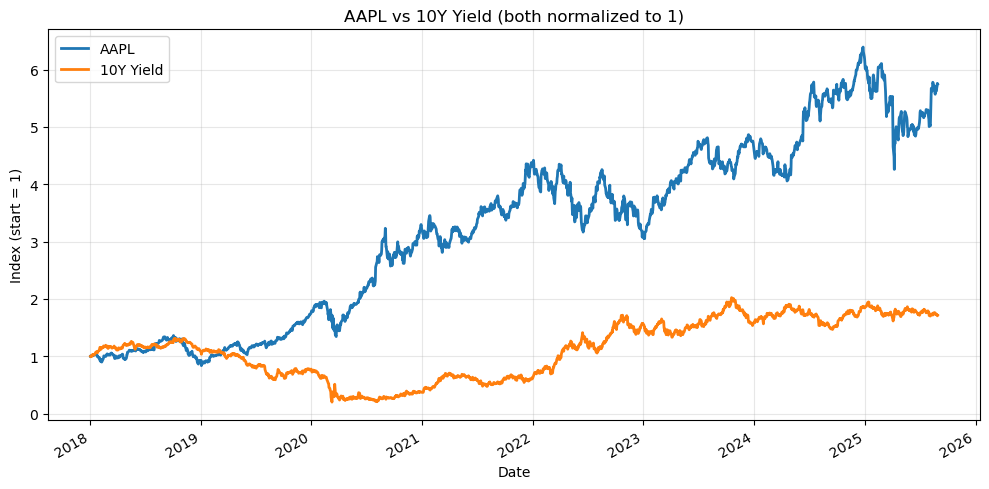

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

tickers = ["AAPL", "^TNX"]  #stock, macro proxy (10 year yield)
data = yf.download(tickers, start="2018-01-01", auto_adjust=True, progress=False)["Close"].dropna()

if "^TNX" in data.columns:
    data["^TNX_pct"] = data["^TNX"] / 10
    macro_col = "^TNX_pct"
else:
  macro_col = data.column[1]

#dropping rows with NaN
data = data.dropna()

# Normalize both to start at 1 (your earlier trick)
norm = pd.DataFrame({
    "Stock_Index": data["AAPL"] / data["AAPL"].iloc[0],
    "Macro_Index": data[macro_col] / data[macro_col].iloc[0],
}).dropna()

ax = norm.plot(figsize=(10,5), linewidth=2)
ax.set_title("AAPL vs 10Y Yield (both normalized to 1)")
ax.set_xlabel("Date")
ax.set_ylabel("Index (start = 1)")
ax.grid(True, alpha=0.3)
ax.legend(["AAPL", "10Y Yield"])
plt.tight_layout(); plt.show()
